In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np

place = "Makassar, Indonesia"

gdf = ox.geocode_to_gdf(place)

print("=== ORIGINAL CRS ===")
print(gdf.crs)

gdf = gdf.to_crs(epsg=32750)  # UTM Zone 50S (meter-based)

print("\n=== AREA COMPUTATION ===")
area_m2 = gdf.geometry.area.values[0]
area_km2 = area_m2 / 1e6

print("Luas Makassar (km²):", area_km2)

=== ORIGINAL CRS ===
epsg:4326

=== AREA COMPUTATION ===
Luas Makassar (km²): 176.8487558498523


In [2]:
cell_size = 250  # meters (FIXED TRUE SCALE)

In [3]:
minx, miny, maxx, maxy = gdf.total_bounds

print("\n=== BOUNDING BOX ===")
print("minx:", minx)
print("miny:", miny)
print("maxx:", maxx)
print("maxy:", maxy)


=== BOUNDING BOX ===
minx: 729948.3919321242
miny: 9421133.63990883
maxx: 781988.5856939678
maxy: 9449683.913701328


In [4]:
lons = np.arange(minx, maxx, cell_size)
lats = np.arange(miny, maxy, cell_size)

grid_points = []
grid_id = 0

for x in lons:
    for y in lats:
        grid_points.append({
            "grid_id": grid_id,
            "x": x,
            "y": y
        })
        grid_id += 1

grid = pd.DataFrame(grid_points)

print("\n=== RAW GRID (BEFORE CLIP) ===")
print("Total grid (bounding box):", len(grid))


=== RAW GRID (BEFORE CLIP) ===
Total grid (bounding box): 24035


In [5]:
from shapely.geometry import Point

grid["geometry"] = grid.apply(lambda row: Point(row["x"], row["y"]), axis=1)

grid_gdf = gpd.GeoDataFrame(grid, geometry="geometry", crs="EPSG:32750")

print("\nGrid GeoDataFrame created")
print(grid_gdf.head())


Grid GeoDataFrame created
   grid_id              x             y                        geometry
0        0  729948.391932  9.421134e+06  POINT (729948.392 9421133.640)
1        1  729948.391932  9.421384e+06  POINT (729948.392 9421383.640)
2        2  729948.391932  9.421634e+06  POINT (729948.392 9421633.640)
3        3  729948.391932  9.421884e+06  POINT (729948.392 9421883.640)
4        4  729948.391932  9.422134e+06  POINT (729948.392 9422133.640)


In [6]:
gdf_boundary = gdf[["geometry"]]

grid_clipped = gpd.sjoin(
    grid_gdf,
    gdf_boundary,
    predicate="within",
    how="inner"
)

In [7]:
print("\n=== FINAL GRID (AFTER CLIP) ===")
print("Total grid inside Makassar:", len(grid_clipped))

print("\n=== ESTIMATION CHECK ===")
estimated = area_km2 / (0.25 * 0.25)
print("Estimated grid (theoretical):", int(estimated))
print("Actual grid:", len(grid_clipped))

print("\n=== RATIO CHECK ===")
ratio = len(grid_clipped) / estimated
print("Actual / Estimated ratio:", ratio)

print("\n=== SAMPLE ===")
print(grid_clipped.head())


=== FINAL GRID (AFTER CLIP) ===
Total grid inside Makassar: 2834

=== ESTIMATION CHECK ===
Estimated grid (theoretical): 2829
Actual grid: 2834

=== RATIO CHECK ===
Actual / Estimated ratio: 1.0015620361524185

=== SAMPLE ===
      grid_id              x             y                        geometry  \
227       227  730198.391932  9.449134e+06  POINT (730198.392 9449133.640)   
1009     1009  731948.391932  9.443384e+06  POINT (731948.392 9443383.640)   
1124     1124  732198.391932  9.443384e+06  POINT (732198.392 9443383.640)   
1125     1125  732198.391932  9.443634e+06  POINT (732198.392 9443633.640)   
1239     1239  732448.391932  9.443384e+06  POINT (732448.392 9443383.640)   

      index_right  
227             0  
1009            0  
1124            0  
1125            0  
1239            0  


In [8]:
import matplotlib.pyplot as plt

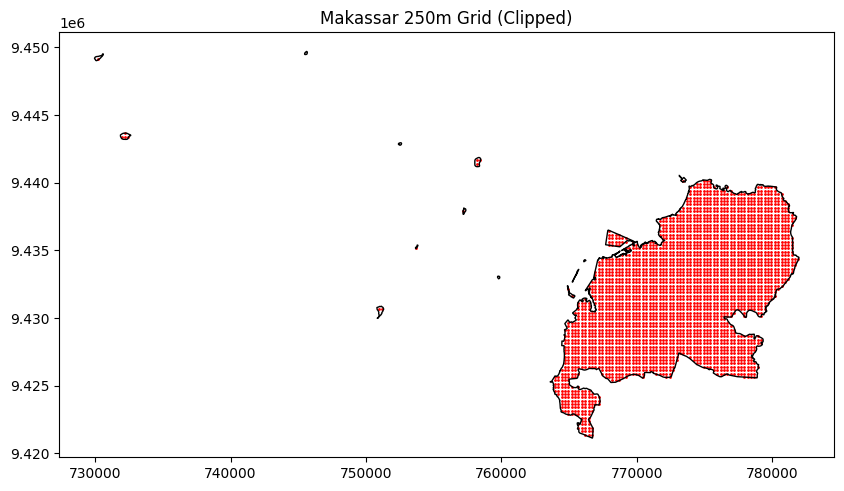

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot boundary Makassar
gdf.boundary.plot(ax=ax, color="black", linewidth=1)

# Plot grid points
grid_clipped.plot(
    ax=ax,
    color="red",
    markersize=1
)

plt.title("Makassar 250m Grid (Clipped)")
plt.show()

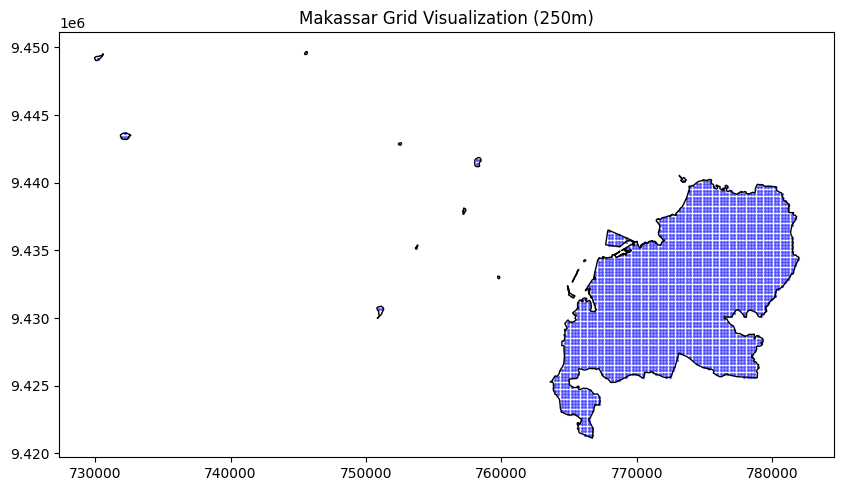

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.boundary.plot(ax=ax, color="black", linewidth=1)

grid_clipped.plot(
    ax=ax,
    color="blue",
    markersize=2,
    alpha=0.5
)

plt.title("Makassar Grid Visualization (250m)")
plt.show()

In [11]:
print("GRID CRS:", grid_clipped.crs)
print("BOUNDARY CRS:", gdf.crs)
print("GRID COUNT:", len(grid_clipped))

GRID CRS: EPSG:32750
BOUNDARY CRS: EPSG:32750
GRID COUNT: 2834


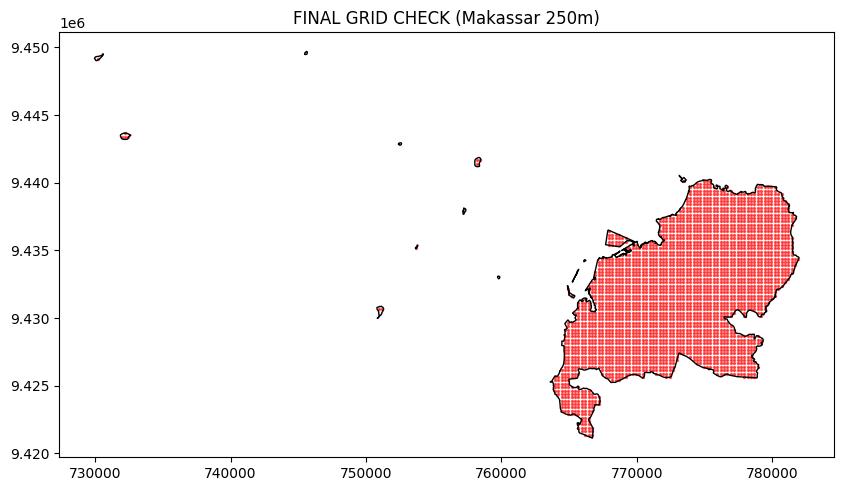

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# boundary
gdf.boundary.plot(ax=ax, color="black", linewidth=1)

# grid
grid_clipped.plot(
    ax=ax,
    color="red",
    markersize=2,
    alpha=0.6
)

plt.title("FINAL GRID CHECK (Makassar 250m)")
plt.show()

In [13]:
%pip install pyarrow --prefer-binary

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
from pathlib import Path

# Get project root path - works in both scripts and Jupyter
try:
    # Running as script
    PROJECT_ROOT = Path(__file__).parent.parent
except NameError:
    # Running in Jupyter notebook
    import os
    cwd = Path.cwd()
    
    # If we're in notebooks folder, go up to project root
    if cwd.name == "notebooks":
        PROJECT_ROOT = cwd.parent
    else:
        PROJECT_ROOT = cwd

# Create data/processed folder
data_processed = PROJECT_ROOT / "data" / "processed"
data_processed.mkdir(parents=True, exist_ok=True)

# Save parquet
parquet_path = data_processed / "makassar_grid_250m.parquet"
grid_clipped.to_parquet(parquet_path, index=False)

print(f"✔ GRID SAVED -> {parquet_path}")
print(f"   File size: {parquet_path.stat().st_size / 1e6:.2f} MB")

✔ GRID SAVED -> /workspaces/flood-ml-research/data/processed/makassar_grid_250m.parquet
   File size: 0.05 MB


In [15]:
from pathlib import Path

# Get project root path - works in both scripts and Jupyter
try:
    PROJECT_ROOT = Path(__file__).parent.parent
except NameError:
    import os
    cwd = Path.cwd()
    if cwd.name == "notebooks":
        PROJECT_ROOT = cwd.parent
    else:
        PROJECT_ROOT = cwd

# Save CSV
data_processed = PROJECT_ROOT / "data" / "processed"
csv_path = data_processed / "makassar_grid_250m.csv"
grid_clipped.drop(columns="geometry").to_csv(csv_path, index=False)

print(f"✔ GRID CSV SAVED -> {csv_path}")

✔ GRID CSV SAVED -> /workspaces/flood-ml-research/data/processed/makassar_grid_250m.csv
